# ChestAI -- M1 training data pipeline (CT-RATE or a local DICOM folder)

One pipeline for both file types. You choose the data source **when you run the notebook**:

- **`ctrate`** -- downloads a CT-RATE subset (NIfTI) from Hugging Face: `N_TRAIN`+`N_VAL` scans from its official TRAIN pool, `N_TEST` scans from its official VALID pool (the benchmark set), all in one run.
- **`folder`** -- any folder of DICOM series or NIfTI files, e.g. a mounted Google Drive, an SSD or a server folder.
  The folder can have any layout: every DICOM *series* (grouped by SeriesInstanceUID, not just folder location) or NIfTI file is one scan. `N_TRAIN`/`N_VAL`/`N_TEST` patients are picked at random (seeded) from whatever is found.

No labels are read or produced anywhere in this notebook -- M1 only ever builds images, patient ids and splits. A separate step (M4) joins labels by volume_id when it needs them for supervision.

Everything after the source is chosen (manifest, preprocessing, QC, montages) is identical for both.

**Before you start**
1. For `ctrate`: accept the terms at https://huggingface.co/datasets/ibrahimhamamci/CT-RATE and add a Colab secret named `HF_TOKEN` (key icon, left sidebar; turn on Notebook access).
2. For a Drive folder that was *shared with you*: in Google Drive, right-click the folder -> **Organize -> Add shortcut** -> My Drive. Colab's mount only shows My Drive, so the shortcut is what makes it visible.
3. Run the cells in order. Step 4 is the only place you need to change anything.

For the single/batch inference entry point, use the separate `ChestAI_M1_inference.ipynb` notebook instead -- it shares this same installed package but never builds a manifest or a split.

## 1. Upload and extract the project zip

In [1]:
import shutil
from pathlib import Path

zip_candidates = sorted(Path("/content").glob("*.zip"))
if not zip_candidates:
    from google.colab import files
    print("No zip found in /content yet -- pick your project zip to upload:")
    uploaded = files.upload()
    zip_candidates = [Path("/content") / name for name in uploaded.keys()]

zip_path = zip_candidates[0]
print("Using zip:", zip_path)

Using zip: /content/ChestCT-Multi-Abnormality-Classifier.zip


In [2]:
import zipfile

PROJECT_DIR = Path("/content/ChestCT-Multi-Abnormality-Classifier")
extract_dir = Path("/content/_extracted")

for d in (PROJECT_DIR, extract_dir):
    if d.exists():
        shutil.rmtree(d)
extract_dir.mkdir()

with zipfile.ZipFile(zip_path) as zf:
    zf.extractall(extract_dir)

entries = list(extract_dir.iterdir())
if len(entries) == 1 and entries[0].is_dir():
    shutil.move(str(entries[0]), str(PROJECT_DIR))
else:
    shutil.move(str(extract_dir), str(PROJECT_DIR))

print("Project extracted to:", PROJECT_DIR)

Project extracted to: /content/ChestCT-Multi-Abnormality-Classifier


## 2. Install

In [3]:
%cd /content/ChestCT-Multi-Abnormality-Classifier
!pip install -q -e ".[dev]"
!pip install -q huggingface_hub
!python -c "import torch" 2>/dev/null || pip install -q torch

/content/ChestCT-Multi-Abnormality-Classifier
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 31.2 MB/s eta 0:00:00
  Building editable for chestct (pyproject.toml) ... done


If step 6 later says the DICOM pixel data cannot be decoded (compressed files), set this to `True`, run it, and re-run from step 5.

In [4]:
INSTALL_DICOM_CODECS = False #@param {type:"boolean"}
if INSTALL_DICOM_CODECS:
    !pip install -q pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg

## 3. Check the compute available

In [5]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
DEVICE = "auto" if torch.cuda.is_available() else "cpu"
print("preprocessing device:", DEVICE)

CUDA available: False
preprocessing device: cpu


## 4. Choose the data source  (the only cell you edit)

| Setting | `ctrate` | `folder` |
|---|---|---|
| `SOURCE_KIND` | `ctrate` | `folder` |
| `SOURCE_NAME` | any tag you like, e.g. `ctrate` (written into the manifest; no spaces -- see the check below) | any tag you like, e.g. `nhrd_local` |
| what to fetch | `MAX_COMBINED_GB` (optional memory screen) | `DATA_ROOT` |
| `STAGE_LOCAL` | not used | copy to the runtime's local disk first (recommended for Drive: much faster) |

`N_TRAIN`/`N_VAL`/`N_TEST` and `SEED` work the same way for both sources: exactly that many PATIENTS are picked at random (not "the first N alphabetically"), and the same seed always reproduces the same pick. For CT-RATE, `N_TEST` comes from its own official VALID pool (never mixed with train/val); for a folder, all three amounts are drawn from the same discovered pool.

`APPEND` adds this source to the existing manifest instead of replacing it -- run once for CT-RATE, then again for the local data.

In [18]:
SOURCE_KIND = "folder" #@param ["ctrate", "folder"]
SOURCE_NAME = "nhrd-ct-rate" #@param {type:"string"}
APPEND = False #@param {type:"boolean"}
WORKERS = 1 #@param {type:"integer"}

N_TRAIN = 4 #@param {type:"integer"}
N_VAL = 2 #@param {type:"integer"}
N_TEST = 1 #@param {type:"integer"}
SEED = 0 #@param {type:"integer"}

# --- ctrate only
MAX_COMBINED_GB = 1.5 #@param {type:"number"}

# --- folder only
DATA_ROOT = "/content/drive/MyDrive/NHRD - CT Scan" #@param {type:"string"}
STAGE_LOCAL = True #@param {type:"boolean"}
PATIENT_PATH_DEPTH = 1 #@param {type:"integer"}

import shlex
if not SOURCE_NAME.strip() or set(" \t\'\"") & set(SOURCE_NAME):
    raise ValueError(f"SOURCE_NAME {SOURCE_NAME!r} must be non-empty and must not contain spaces or quotes")
SOURCE_NAME_Q = shlex.quote(SOURCE_NAME)
print(f"source: {SOURCE_KIND} ({SOURCE_NAME})")

source: folder (nhrd-ct-rate)


## 5. Get the scans

`ctrate`: downloads from Hugging Face in one combined run (fast: it never lists the whole repository). `folder`: mounts Drive if the path is on it, then copies the whole folder to local disk -- random selection happens later, at the manifest step, over everything found.

In [19]:
from pathlib import Path

if SOURCE_KIND == "ctrate":
    from google.colab import userdata
    from huggingface_hub import login
    login(token=userdata.get("HF_TOKEN"))
    cmd = (f"python scripts/download_subset.py --n-train {N_TRAIN} --n-val {N_VAL} --n-test {N_TEST} "
           f"--seed {SEED} --out-dir data/raw --no-chest-filter")
    if MAX_COMBINED_GB:
        cmd += f" --max-combined-gb {MAX_COMBINED_GB}"
    !{cmd}
    SCAN_ROOT = "data/raw"
else:
    if DATA_ROOT.startswith("/content/drive") and not Path("/content/drive/MyDrive").exists():
        from google.colab import drive
        drive.mount("/content/drive")
    if not Path(DATA_ROOT).is_dir():
        raise FileNotFoundError(
            f"{DATA_ROOT!r} was not found. For a folder shared with you, add a shortcut to My Drive first "
            f"(right-click -> Organize -> Add shortcut). My Drive currently contains: "
            f"{sorted(p.name for p in Path('/content/drive/MyDrive').glob('*'))[:20]}")
    if STAGE_LOCAL:
        SCAN_ROOT = f"/content/local_scans/{SOURCE_NAME}"
        !python scripts/stage_folder.py --src {shlex.quote(DATA_ROOT)} --dst {shlex.quote(SCAN_ROOT)}
    else:
        SCAN_ROOT = DATA_ROOT
SCAN_ROOT_Q = shlex.quote(SCAN_ROOT)
print("scans are in:", SCAN_ROOT)

Mounted at /content/drive
2585 files: 2585 copied, 0 already there (1112 MB, 133s) -> /content/local_scans/nhrd-ct-rate
scans are in: /content/local_scans/nhrd-ct-rate


## 6. Look at what the DICOM tags contain  (`folder` only)

Header-only and quick. Shows the acquisition fields, the compression type, whether slice spacing is uniform, and whether each folder carries a distinct patient id (shown as a short hash, not the value).

In [21]:
if SOURCE_KIND == "folder":
    !python scripts/dicom_tags.py {SCAN_ROOT_Q} --max 7
else:
    print("not needed for CT-RATE")

=== 4203-26/P00001/S0001
  n_files: 363
  manufacturer: TOSHIBA
  model: Alexion
  kernel: FC81
  slice_thickness: 1.0
  series_description: 
  contrast: False
  transfer_syntax: JPEG 2000 Image Compression (Lossless Only)
  n_series: 1
  rows: 512
  cols: 512
  photometric: MONOCHROME2
  modality: CT
  z_spacing: 0.7999999999999545
  z_uniform: True
  tilt_deg: 0.0
  row_spacing: 0.681
  col_spacing: 0.681
  patient_id_present: False
  patient_id_hash: 
  has_study_uid: True
  has_series_uid: True
=== 4213-26/P00001/S0001
  n_files: 281
  manufacturer: TOSHIBA
  model: Alexion
  kernel: FC81
  slice_thickness: 1.0
  series_description: 
  contrast: False
  transfer_syntax: Implicit VR Little Endian
  n_series: 1
  rows: 512
  cols: 512
  photometric: MONOCHROME2
  modality: CT
  z_spacing: 0.7999999999999545
  z_uniform: True
  tilt_deg: 0.0
  row_spacing: 0.761
  col_spacing: 0.761
  patient_id_present: False
  patient_id_hash: 
  has_study_uid: True
  has_series_uid: True
=== 4214-2

## 7. Build the manifest

No labels are read or written here for either source -- only image identity, patient id and split. For CT-RATE, both the TRAIN and VALID pools' metadata (RescaleSlope/Intercept, spacing, ...) are combined first, since one run now covers both pools at once.

In [22]:
if SOURCE_KIND == "ctrate":
    import pandas as pd
    train_meta = pd.read_csv("data/metadata/train_metadata.csv")
    valid_meta = pd.read_csv("data/metadata/validation_metadata.csv")
    combined_meta_path = "data/metadata/combined_metadata.csv"
    pd.concat([train_meta, valid_meta], ignore_index=True).to_csv(combined_meta_path, index=False)
    cmd = (f"python scripts/build_manifest.py --source-name {SOURCE_NAME_Q} --builder ctrate "
           f"--raw-dir {SCAN_ROOT} --metadata {combined_meta_path} "
           f"--n-train {N_TRAIN} --n-val {N_VAL} --seed {SEED}")
else:
    cmd = (f"python scripts/build_manifest.py --source-name {SOURCE_NAME_Q} --builder folder "
           f"--raw-dir {SCAN_ROOT_Q} --patient-path-depth {PATIENT_PATH_DEPTH} "
           f"--n-train {N_TRAIN} --n-val {N_VAL} --n-test {N_TEST} --seed {SEED}")
if APPEND:
    cmd += " --append"
!{cmd}

note: 'nhrd-ct-rate' is not in configs/data.yaml's `sources:` -- using defaults and command-line values
found 7 scan(s) under /content/local_scans/nhrd-ct-rate
wrote 7 rows to data/manifest.csv (source_name='nhrd-ct-rate')
source_name   split
nhrd-ct-rate  train    4
              val      2
              test     1


In [23]:
import pandas as pd
manifest = pd.read_csv("data/manifest.csv")
print(f"{len(manifest)} rows")
manifest

7 rows


,volume_id,patient_id,scan_path,format,n_files,series_uid,rows,cols,manufacturer,model,kernel,slice_thickness,series_description,contrast,transfer_syntax,split,source_name
0,4203-26_P00001_S0001_s002534.1,4203-26,4203-26/P00001/S0001,dicom,363,2.25.185938969289249819411213875490925002534.1,512,512,TOSHIBA,Alexion,FC81,1.0,NaN,False,JPEG 2000 Image Compression (Lossless Only),train,nhrd-ct-rate
1,4213-26_P00001_S0001_s318449.1,4213-26,4213-26/P00001/S0001,dicom,281,2.25.1368210504494765047612310850248564318449.1,512,512,TOSHIBA,Alexion,FC81,1.0,NaN,False,Implicit VR Little Endian,train,nhrd-ct-rate
2,4214-26_P00001_S0001_s469091.1,4214-26,4214-26/P00001/S0001,dicom,432,2.25.1452483950181870814710713563999161469091.1,512,512,TOSHIBA,Alexion,FC81,1.0,NaN,False,JPEG 2000 Image Compression (Lossless Only),train,nhrd-ct-rate
3,4215-26_P00001_S0001_s000275.1,4215-26,4215-26/P00001/S0001,dicom,388,2.25.35287769708649041019865413285606000275.1,512,512,TOSHIBA,Alexion,FC81,1.0,NaN,False,Implicit VR Little Endian,val,nhrd-ct-rate
4,4216-26_P00001_S0001_s021310.1,4216-26,4216-26/P00001/S0001,dicom,413,2.25.596812245541357344411942587079556021310.1,512,512,TOSHIBA,Alexion,FC81,1.0,NaN,False,Implicit VR Little Endian,train,nhrd-ct-rate
5,4217-26_P00001_S0001_s979548.1,4217-26,4217-26/P00001/S0001,dicom,332,2.25.1366339302044940701710060133835324979548.1,512,512,TOSHIBA,Alexion,FC81,1.0,NaN,False,Implicit VR Little Endian,val,nhrd-ct-rate
6,4222-26_P00001_S0001_s791893.1,4222-26,4222-26/P00001/S0001,dicom,376,2.25.62178806608733335439922644412426791893.1,512,512,TOSHIBA,Alexion,FC81,1.0,NaN,False,JPEG 2000 Image Compression (Lossless Only),test,nhrd-ct-rate


## 8. Preprocess

Uses a GPU for resampling if one was found. Safe to re-run: a scan is only skipped if its cached result came from the same settings *and* the same raw data; otherwise it is reprocessed.

In [24]:
SOURCE_ARG = shlex.quote(f"{SOURCE_NAME}={SCAN_ROOT}")
!python scripts/preprocess_all.py --workers {WORKERS} --device {DEVICE} --source-root {SOURCE_ARG}

7 volumes to process (0 already cached and up to date)
source roots for this run: {'nhrd-ct-rate': '/content/local_scans/nhrd-ct-rate'}
device: cpu, config fingerprint (see stale-cache guard): 8097d13ff9b3a9b8
100% 7/7 [01:28<00:00, 12.69s/it]
done: 7 ok, 0 failed, 88.8s total
avg 12.69s/volume, avg 19.8 MB/volume on disk
updated data/manifest.csv with per-volume preprocessing stats
wrote data/preprocessing_manifest.json


## 9. Quality check

In [25]:
!python scripts/qc_report.py --montage-every 1

7 / 7 passed -> data/qc_report.csv
montages saved to data/qc_montages


In [26]:
qc = pd.read_csv("data/qc_report.csv")
qc

,volume_id,passed,reasons,flags,n_slices,hu_min,hu_max,hu_std
0,4203-26_P00001_S0001_s002534.1,True,NaN,NaN,194,-2048.0,4411.0,631.099186
1,4213-26_P00001_S0001_s318449.1,True,NaN,NaN,150,-2048.0,2030.0,623.787536
2,4214-26_P00001_S0001_s469091.1,True,NaN,NaN,230,-2048.0,4828.0,646.679202
3,4215-26_P00001_S0001_s000275.1,True,NaN,NaN,207,-2048.0,2367.0,663.434931
4,4216-26_P00001_S0001_s021310.1,True,NaN,NaN,220,-2048.0,2212.0,640.513778
5,4217-26_P00001_S0001_s979548.1,True,NaN,NaN,177,-2048.0,2306.0,677.008293
6,4222-26_P00001_S0001_s791893.1,True,NaN,NaN,201,-2048.0,2358.0,702.834399


## 10. Look at the montages

Should show upright chest slices, lungs dark, soft tissue mid-grey (not solid white), in the same orientation for every scan.

25 montage(s)
4203-26_P00001_S0001_s002534.1.png


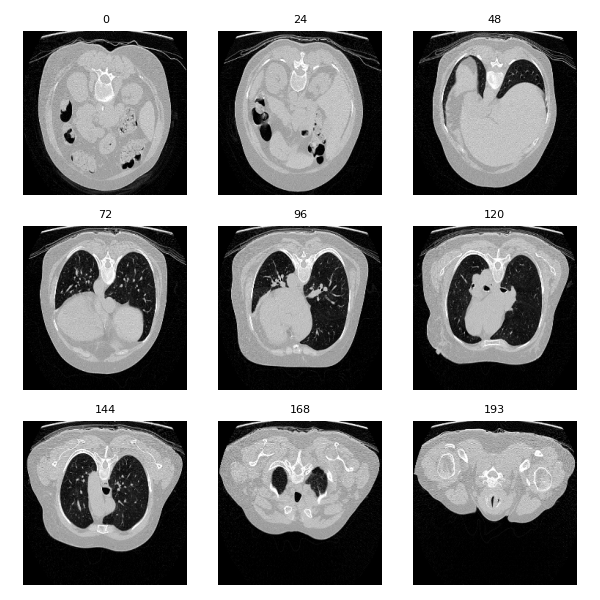

4213-26_P00001_S0001_s318449.1.png


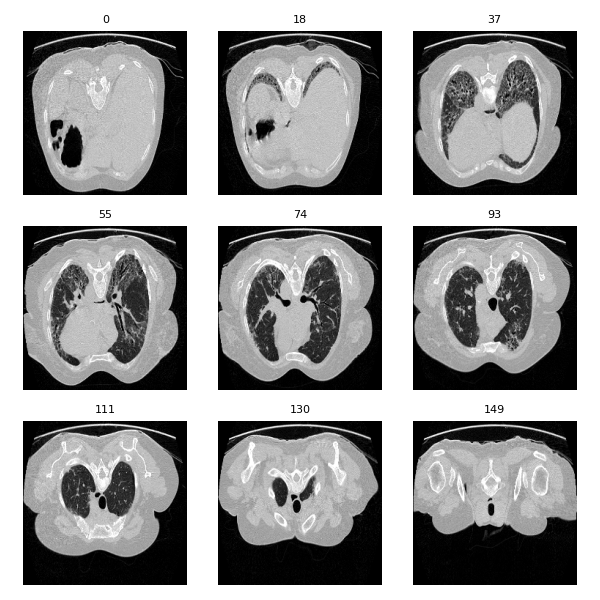

4214-26_P00001_S0001_s469091.1.png


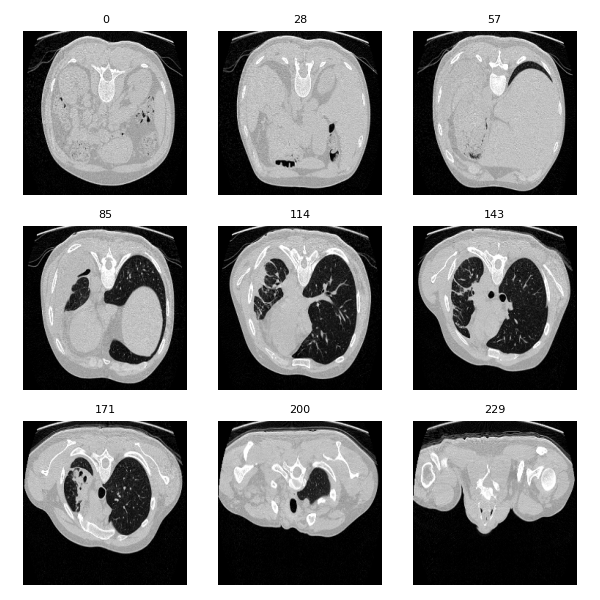

4215-26_P00001_S0001_s000275.1.png


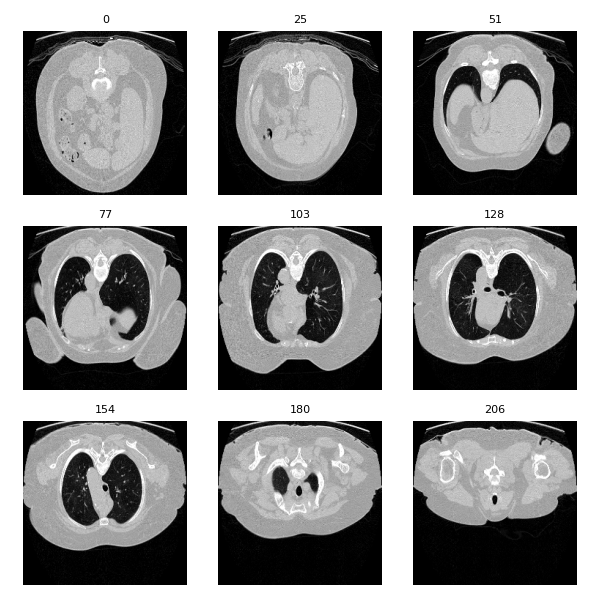

4216-26_P00001_S0001_s021310.1.png


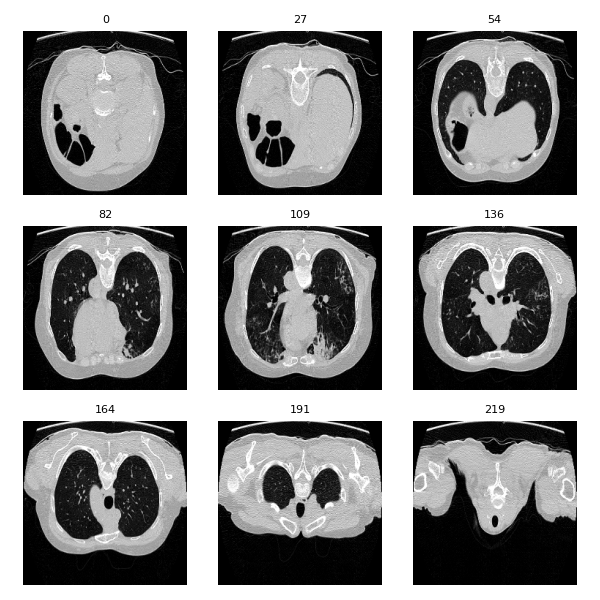

4217-26_P00001_S0001_s979548.1.png


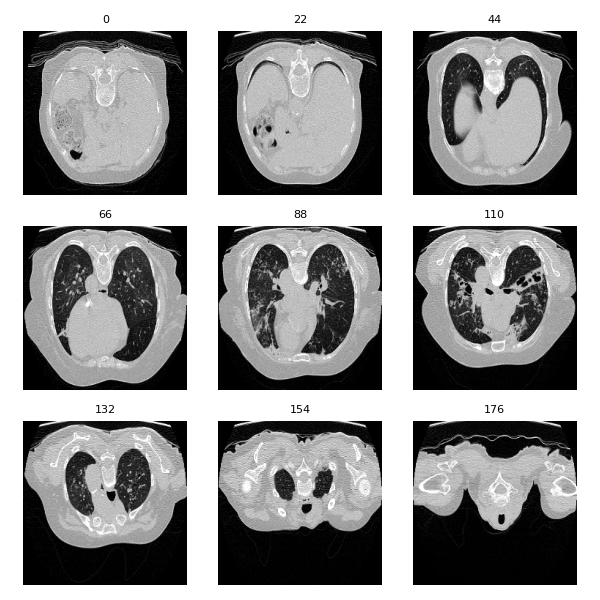

4222-26_P00001_S0001_s791893.1.png


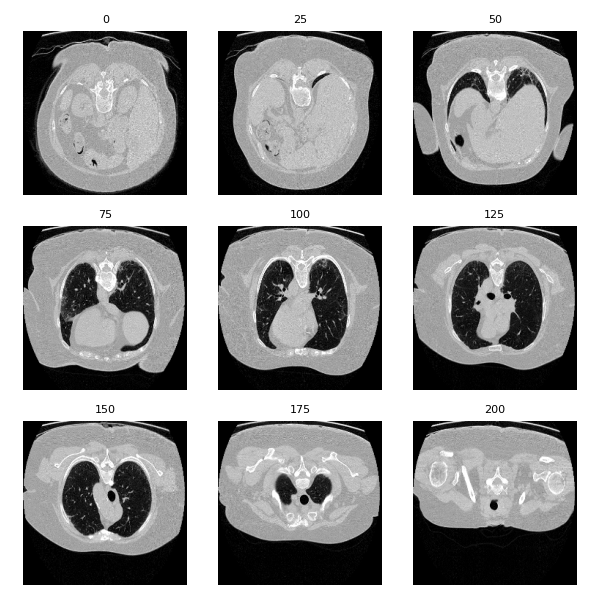

train_10740_a_2.png


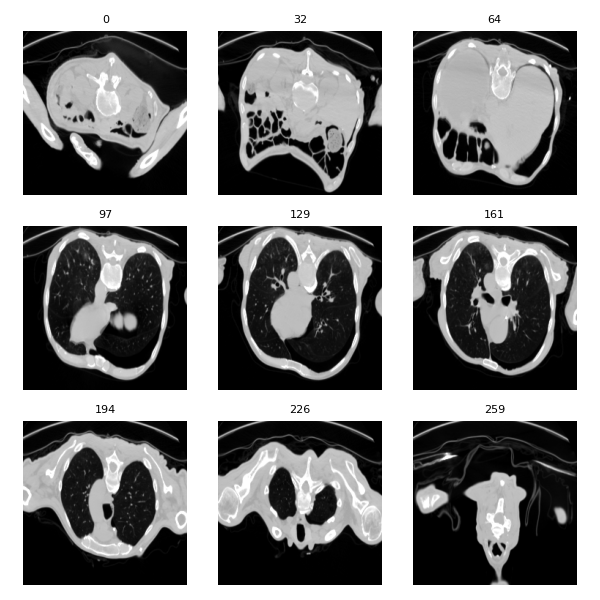

train_11289_a_2.png


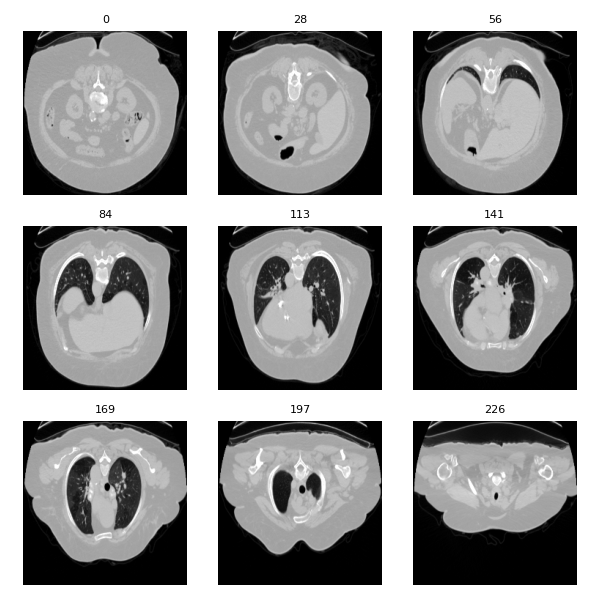

train_1137_a_2.png


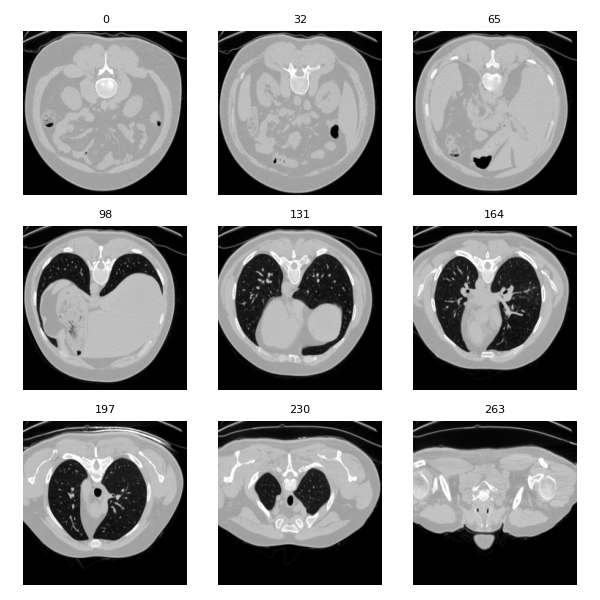

train_11731_a_2.png


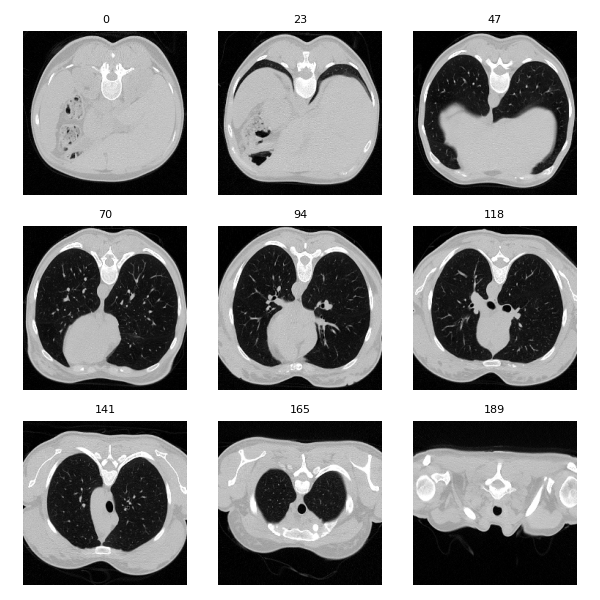

train_13292_a_2.png


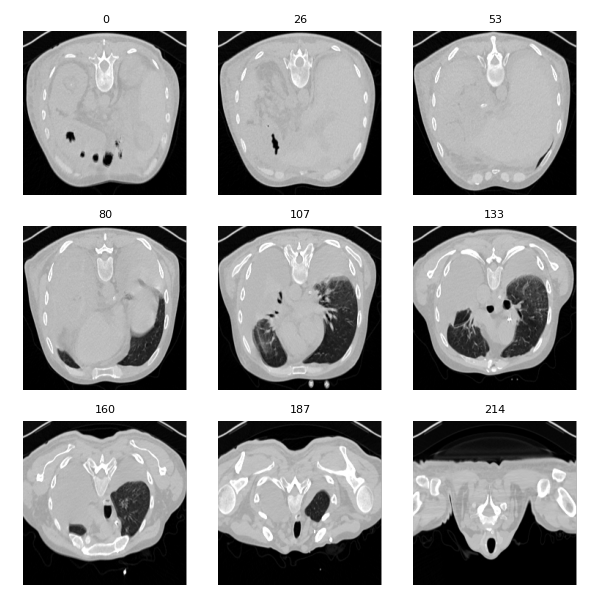

train_13538_a_2.png


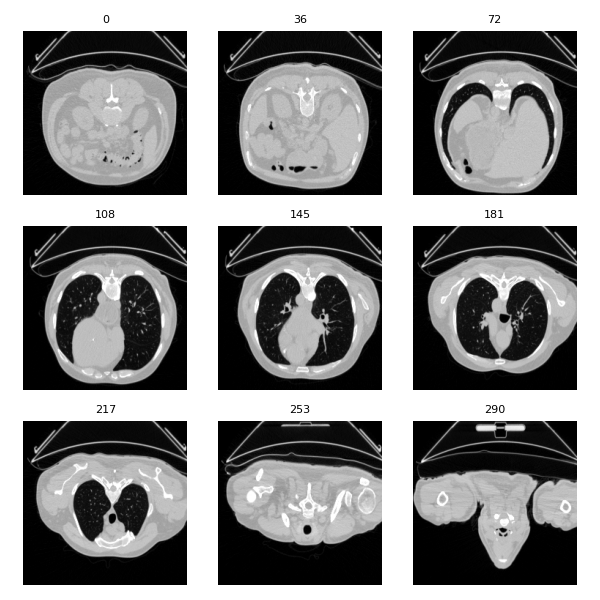

train_14091_b_1.png


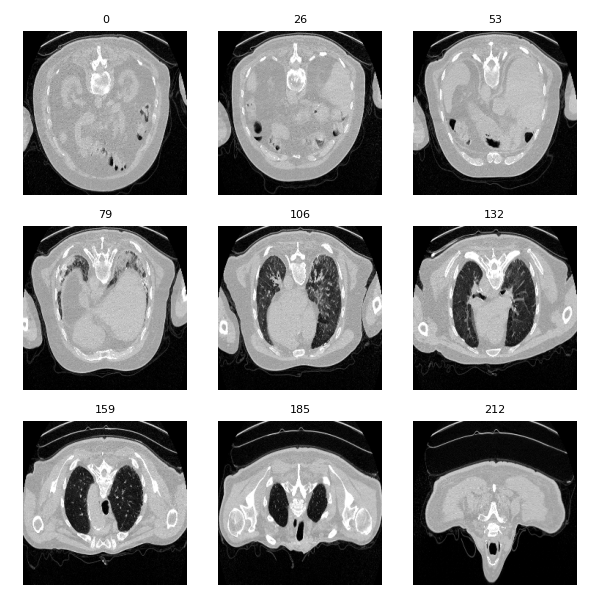

train_14263_a_2.png


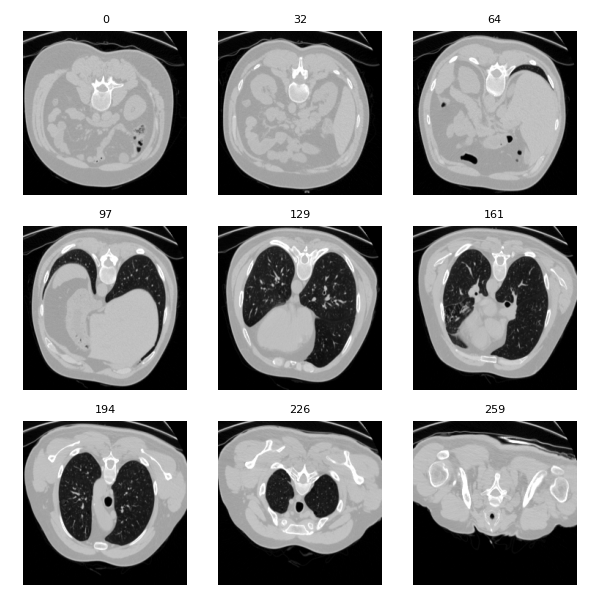

train_16321_a_2.png


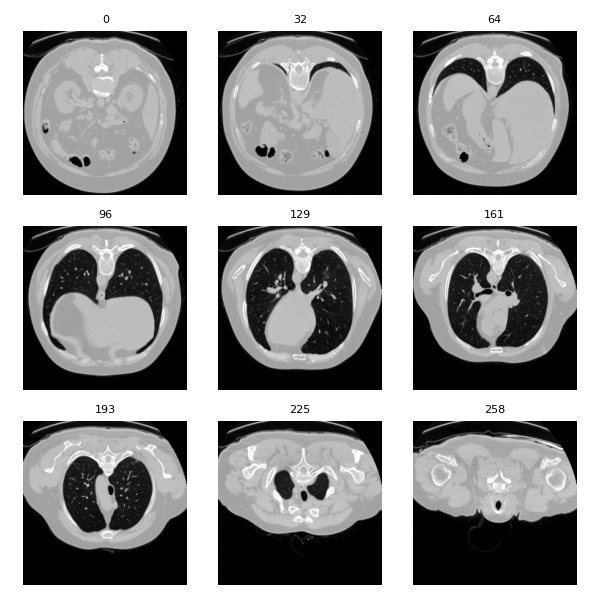

train_3840_b_2.png


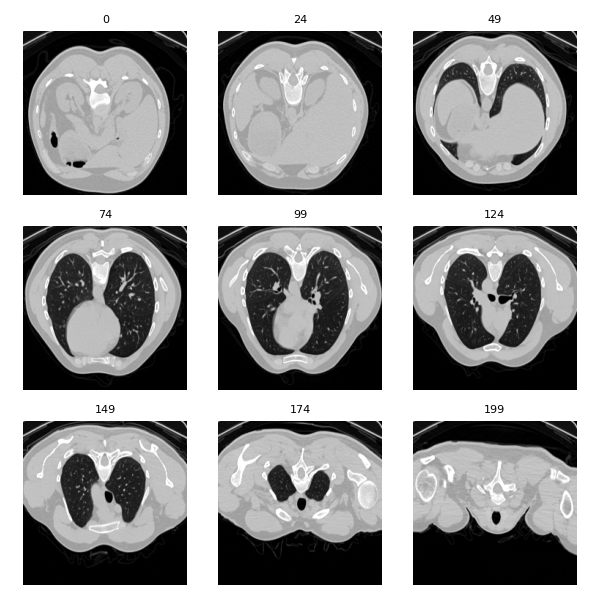

train_6105_a_1.png


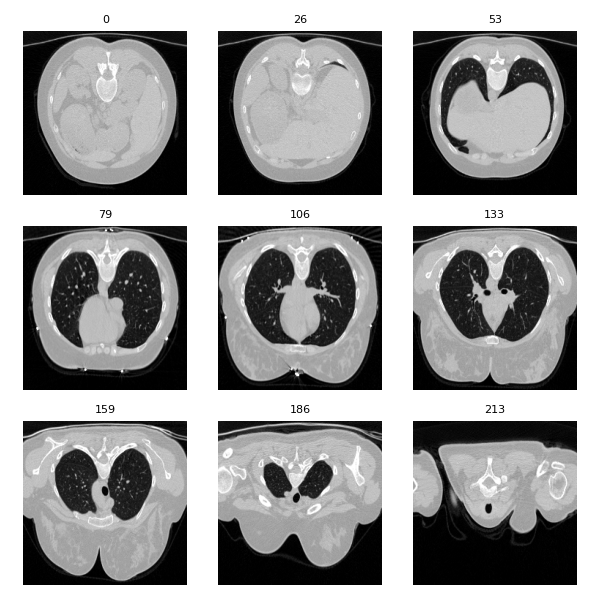

train_7235_a_1.png


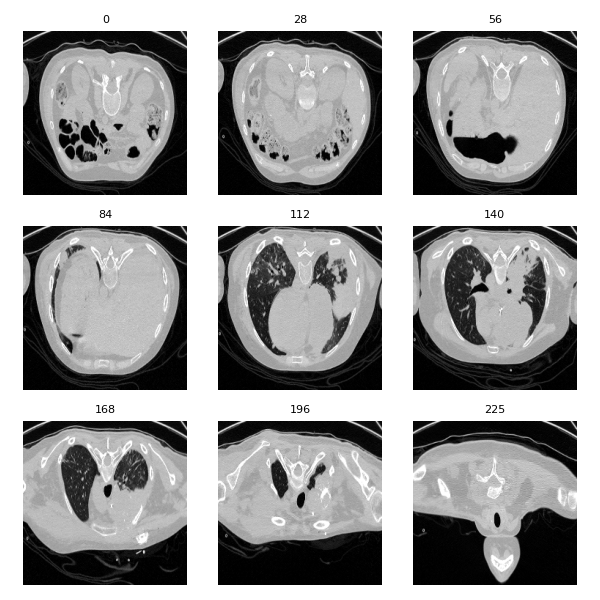

train_8425_a_1.png


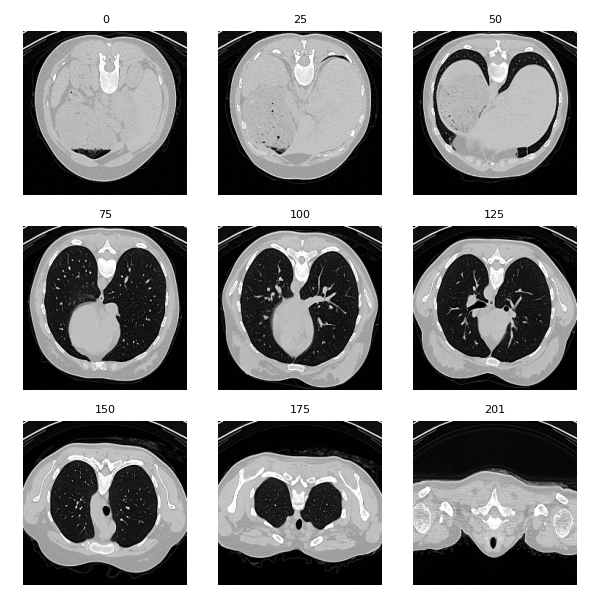

train_9964_a_1.png


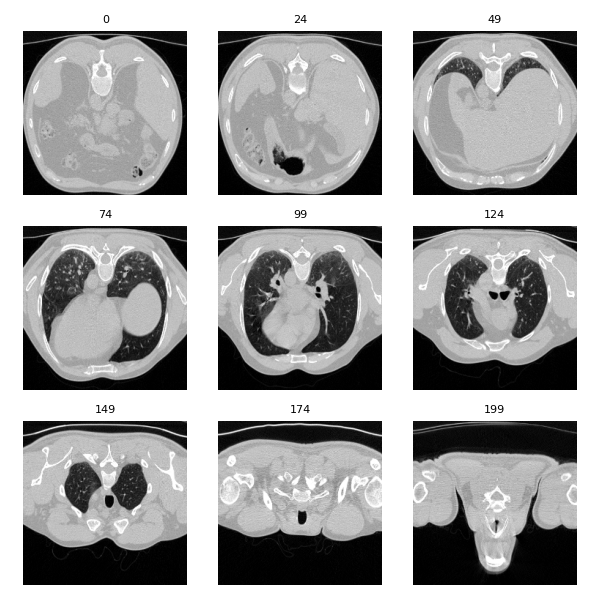

valid_455_a_2.png


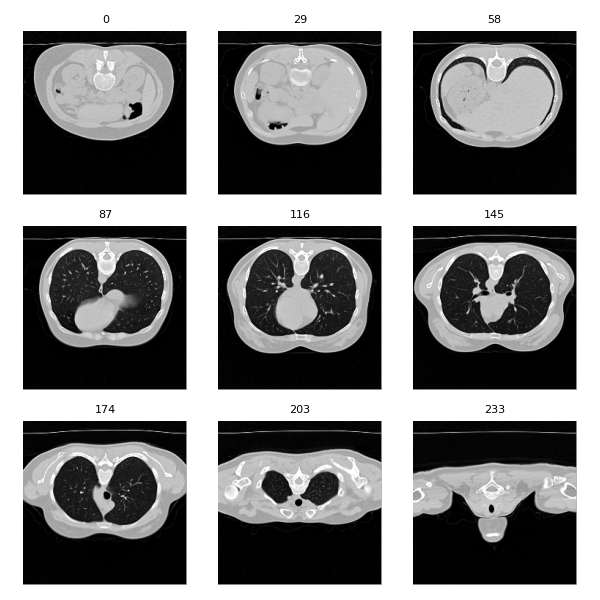

valid_668_b_2.png


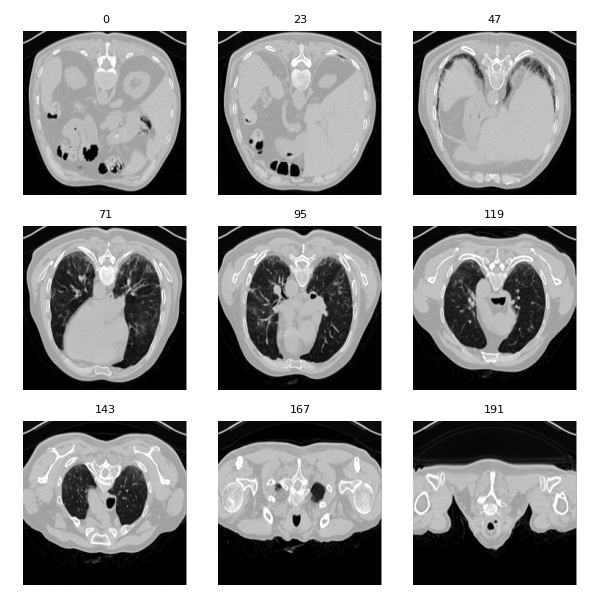

valid_732_a_2.png


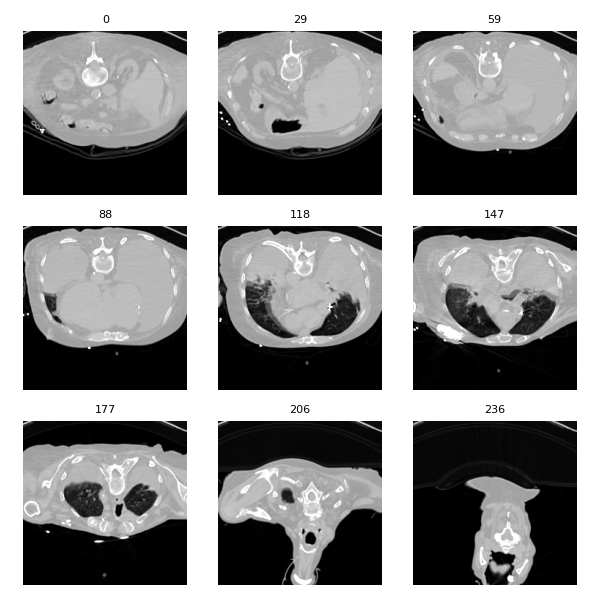

valid_74_a_1.png


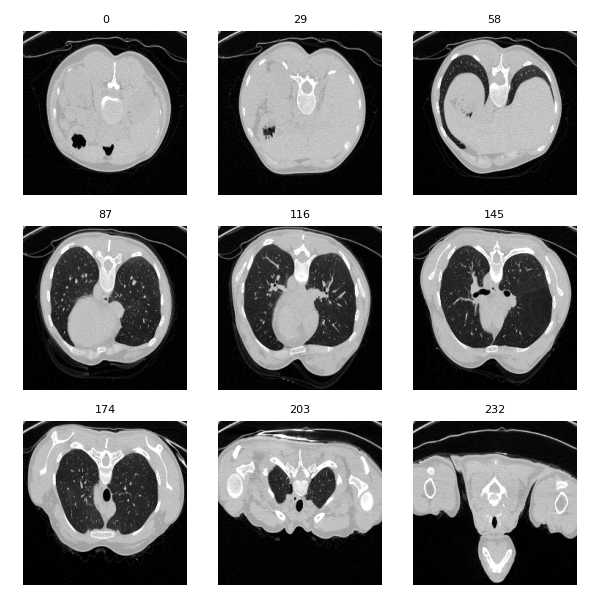

In [27]:
from IPython.display import Image, display
montages = sorted(Path("data/qc_montages").glob("*.png"))
print(f"{len(montages)} montage(s)")
for m in montages:
    print(m.name)
    display(Image(filename=str(m)))

## 11. (Optional) Download the results

Colab's disk is wiped when the session ends. This zips the small outputs (manifest, QC report, cached `.npy`, montages) -- not the raw scans.

In [28]:
import shutil
results_dir = Path("/content/pipeline_results")
if results_dir.exists():
    shutil.rmtree(results_dir)
results_dir.mkdir()
for name in ["manifest.csv", "qc_report.csv", "preprocessing_manifest.json"]:
    src = Path("data") / name
    if src.exists():
        shutil.copy2(src, results_dir / name)
for sub in ["cache", "qc_montages"]:
    src = Path("data") / sub
    if src.exists():
        shutil.copytree(src, results_dir / sub)
archive = shutil.make_archive("/content/pipeline_results", "zip", root_dir=str(results_dir))
from google.colab import files
files.download(archive)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>